In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("emi_cleaned.csv")

df.head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,3,2,0.0,0.0,7200.0,19500.0,13200.0,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,2,1,5100.0,0.0,1400.0,5400.0,3500.0,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,4,3,0.0,0.0,10200.0,19400.0,6000.0,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,5,4,11400.0,0.0,6200.0,11900.0,7900.0,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,4,3,9400.0,21300.0,3600.0,16200.0,8100.0,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


## Dataset Overview

In [3]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 404800
Columns : 27


In [4]:
df[["emi_eligibility","max_monthly_emi"]].head()

,emi_eligibility,max_monthly_emi
0,Not_Eligible,500.0
1,Not_Eligible,700.0
2,Eligible,27775.0
3,Eligible,16170.0
4,Not_Eligible,500.0


## Classification Target Analysis

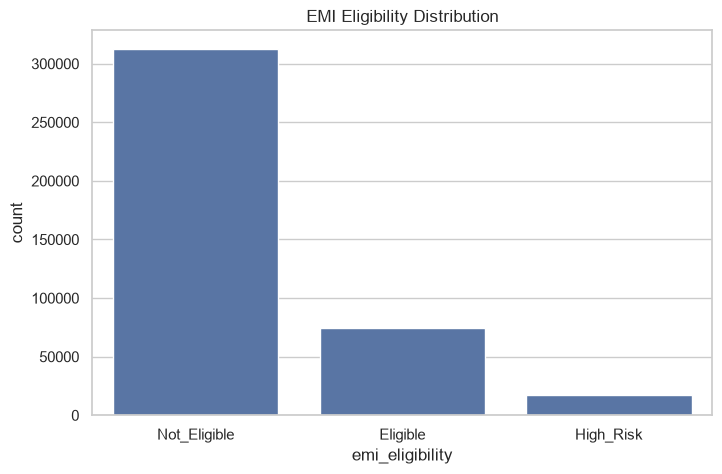

In [5]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="emi_eligibility"
)

plt.title("EMI Eligibility Distribution")

plt.show()

In [6]:
(
df["emi_eligibility"]
.value_counts(normalize=True)
*100
).round(2)

emi_eligibility
Not_Eligible    77.29
Eligible        18.39
High_Risk        4.32
Name: proportion, dtype: float64

Most applicants are classified as Not Eligible.
The dataset is highly imbalanced.
Special handling may be required during model training.

## EMI Scenario Analysis

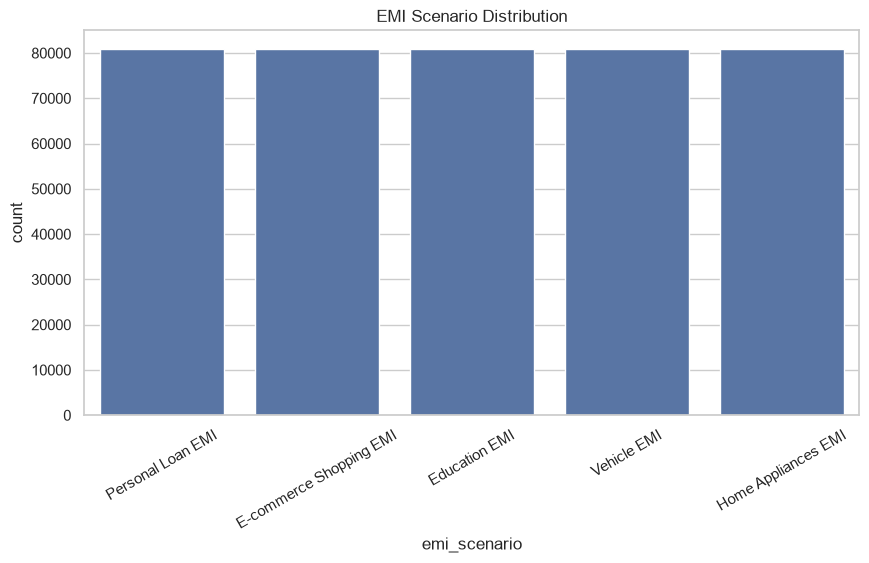

In [7]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="emi_scenario"
)

plt.xticks(rotation=30)

plt.title("EMI Scenario Distribution")

plt.show()

## Credit Score Analysis

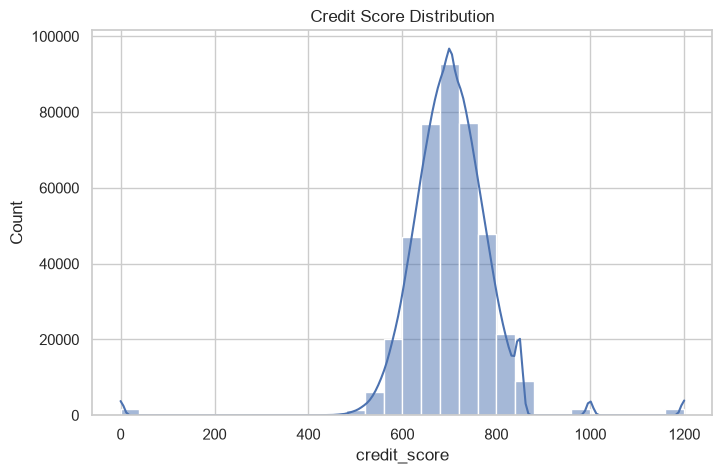

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["credit_score"],
    bins=30,
    kde=True
)

plt.title("Credit Score Distribution")

plt.show()

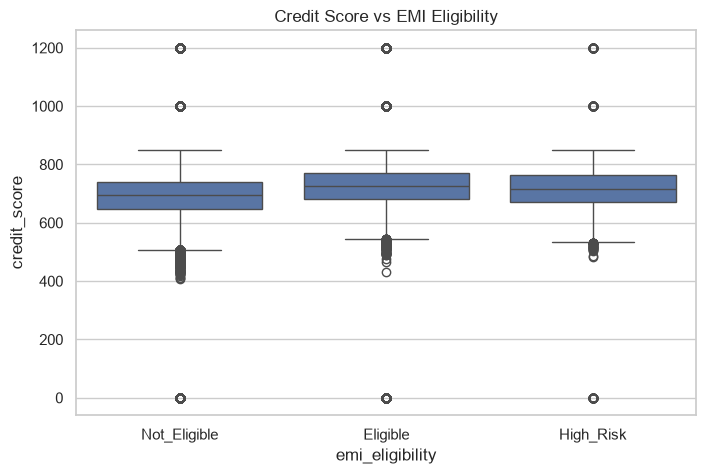

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="emi_eligibility",
    y="credit_score"
)

plt.title("Credit Score vs EMI Eligibility")

plt.show()

## Salary Analysis

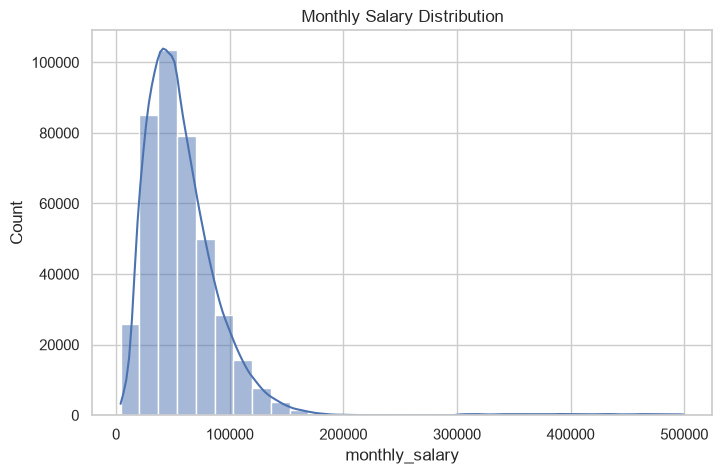

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["monthly_salary"],
    bins=30,
    kde=True
)

plt.title("Monthly Salary Distribution")

plt.show()

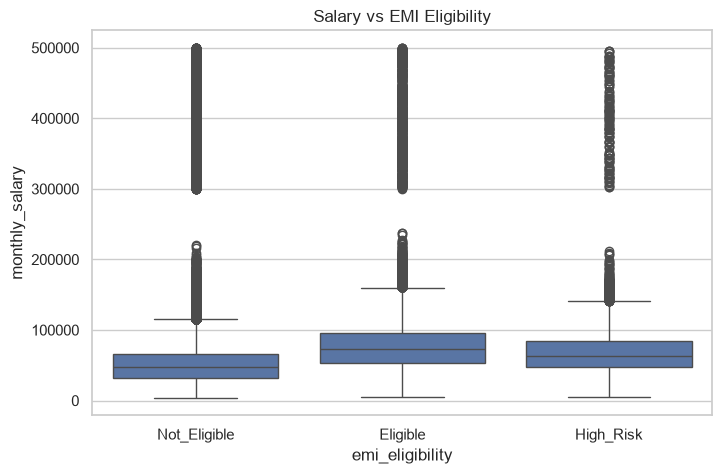

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="emi_eligibility",
    y="monthly_salary"
)

plt.title("Salary vs EMI Eligibility")

plt.show()

## Existing Loan Analysis

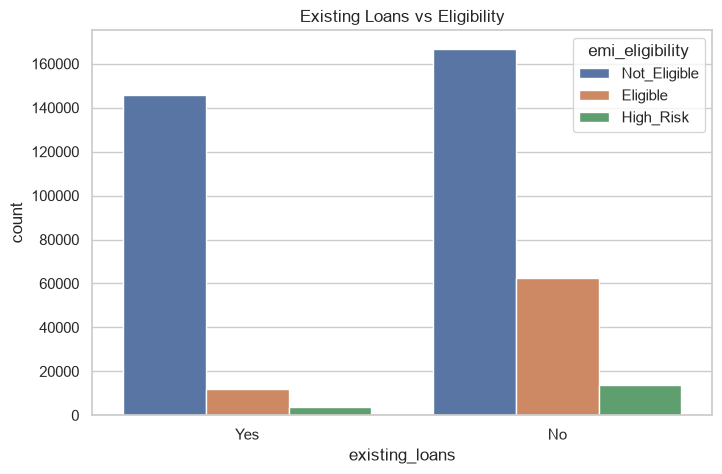

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="existing_loans",
    hue="emi_eligibility"
)

plt.title("Existing Loans vs Eligibility")

plt.show()

## Correlation Analysis

In [13]:
num_df = df.select_dtypes(
    include=["int64","float64"]
)

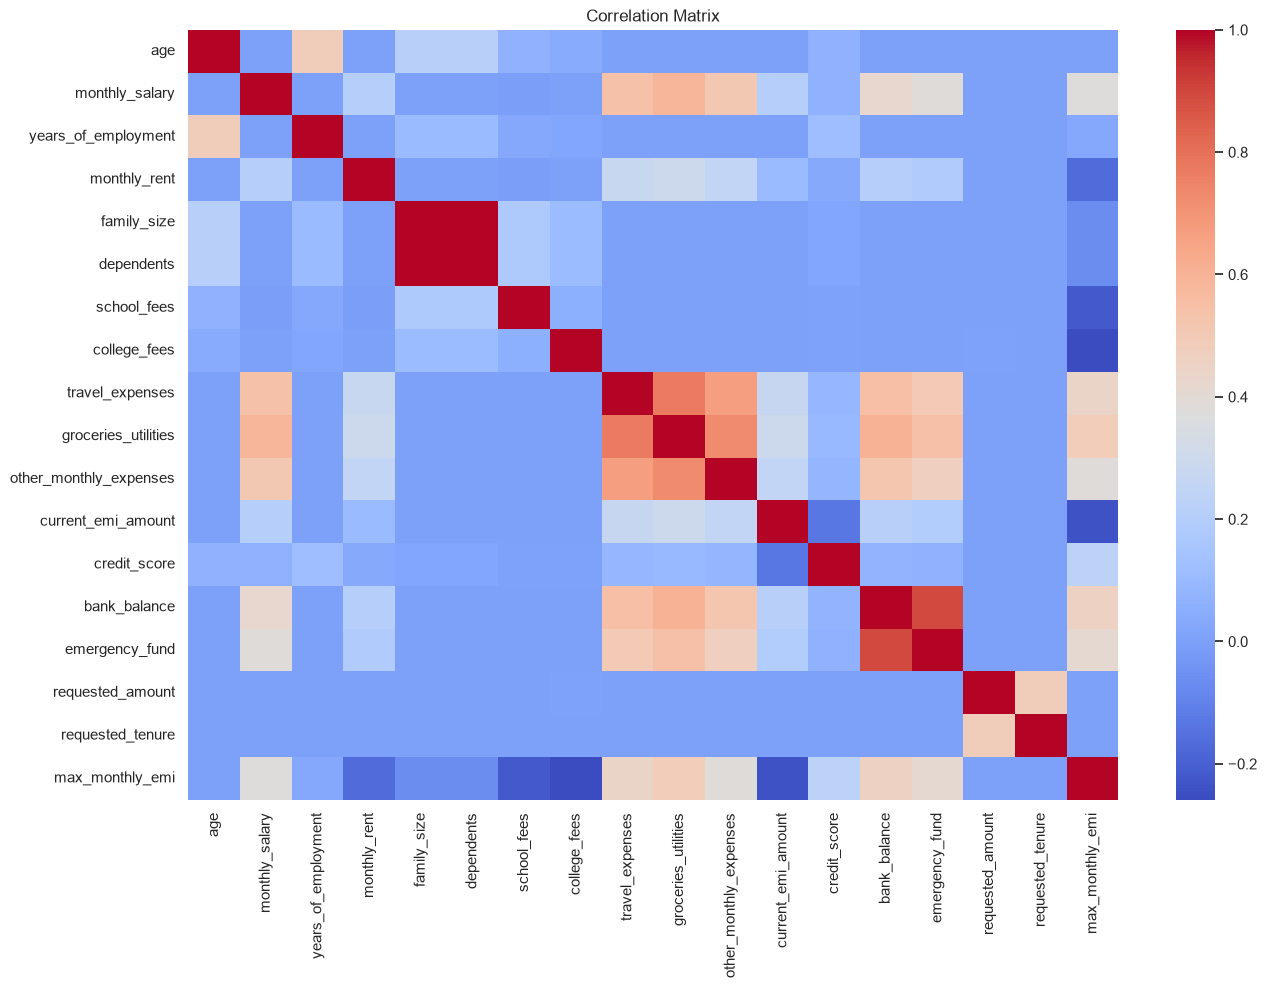

In [14]:
plt.figure(figsize=(15,10))

sns.heatmap(
    num_df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

## Relationship with EMI Amount

In [15]:
corr = num_df.corr()["max_monthly_emi"]

corr.sort_values(ascending=False)

max_monthly_emi           1.000000
groceries_utilities       0.484695
bank_balance              0.456028
travel_expenses           0.440948
emergency_fund            0.414036
other_monthly_expenses    0.382055
monthly_salary            0.378284
credit_score              0.228814
years_of_employment       0.028887
requested_tenure          0.001006
age                      -0.000848
requested_amount         -0.002034
dependents               -0.062266
family_size              -0.062266
monthly_rent             -0.169423
school_fees              -0.215234
current_emi_amount       -0.242434
college_fees             -0.258842
Name: max_monthly_emi, dtype: float64

## Top 10 Important Numeric Features

In [16]:
corr = (
num_df.corr()["max_monthly_emi"]
.abs()
.sort_values(ascending=False)
)

corr.head(10)

max_monthly_emi           1.000000
groceries_utilities       0.484695
bank_balance              0.456028
travel_expenses           0.440948
emergency_fund            0.414036
other_monthly_expenses    0.382055
monthly_salary            0.378284
college_fees              0.258842
current_emi_amount        0.242434
credit_score              0.228814
Name: max_monthly_emi, dtype: float64

## Requested Amount

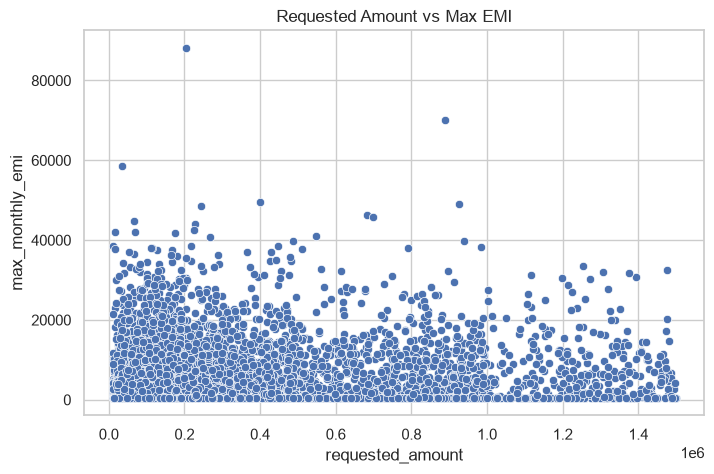

In [17]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df.sample(5000),
    x="requested_amount",
    y="max_monthly_emi"
)

plt.title("Requested Amount vs Max EMI")

plt.show()